# **Day 97: Project 6 - Scene Classification with Self-Supervised Pretraining, Transfer Learning and Grad-CAM**
*Module 13 - Remote Sensing ML and Publication Projects*

Scene classification assigns one label to a whole image patch ("residential", "river", "mine"). It is the RS equivalent of ImageNet: benchmarks such as EuroSAT, BigEarthNet and UC Merced drive much of RS deep-learning research. Labels are expensive, but unlabelled imagery is practically unlimited. That makes **self-supervised pretraining** followed by fine-tuning with few labels the dominant recipe today. It is also how geospatial foundation models (SSL4EO-S12, SatMAE, Prithvi) are built.

> **Working title**: *How many labels does a land-use scene classifier need? Self-supervised pretraining on regional Sentinel-2 imagery vs training from scratch, with Grad-CAM explanations.*

> Scene classification gives one label to a whole image patch. When labels are scarce, a network first learns from many unlabelled patches (self-supervised pretraining) and is then fine-tuned with a few labels. Grad-CAM shows which part of the image it looked at.
>
> *Example:* With only five labelled patches per class, a pretrained network classifies "river" correctly, and Grad-CAM highlights the water channel, not the field beside it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, copy
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import rs_utils as ru
ru.pub_style(); torch.set_num_threads(6)
PROJ = Path("project6_scenes"); PROJ.mkdir(exist_ok=True)
CL = ru.SCENE_CLASSES; K = len(CL)

## **1. Data**
- **Unlabelled pool**: 4,500 patches (48 x 48 px at 10 m, 4 bands), used only for self-supervised pretraining
- **Labelled pool**: 100 per class, from which we draw 5, 20 or 100 labels per class
- **Test (in-season)**: 100 per class, monsoon conditions like the training data
- **Test (dry season)**: 100 per class, vegetation is less green and haze is higher (a domain shift)

{'unlabelled': (4500, 4, 48, 48), 'labelled': (900, 4, 48, 48), 'test': (900, 4, 48, 48), 'test dry': (900, 4, 48, 48)}


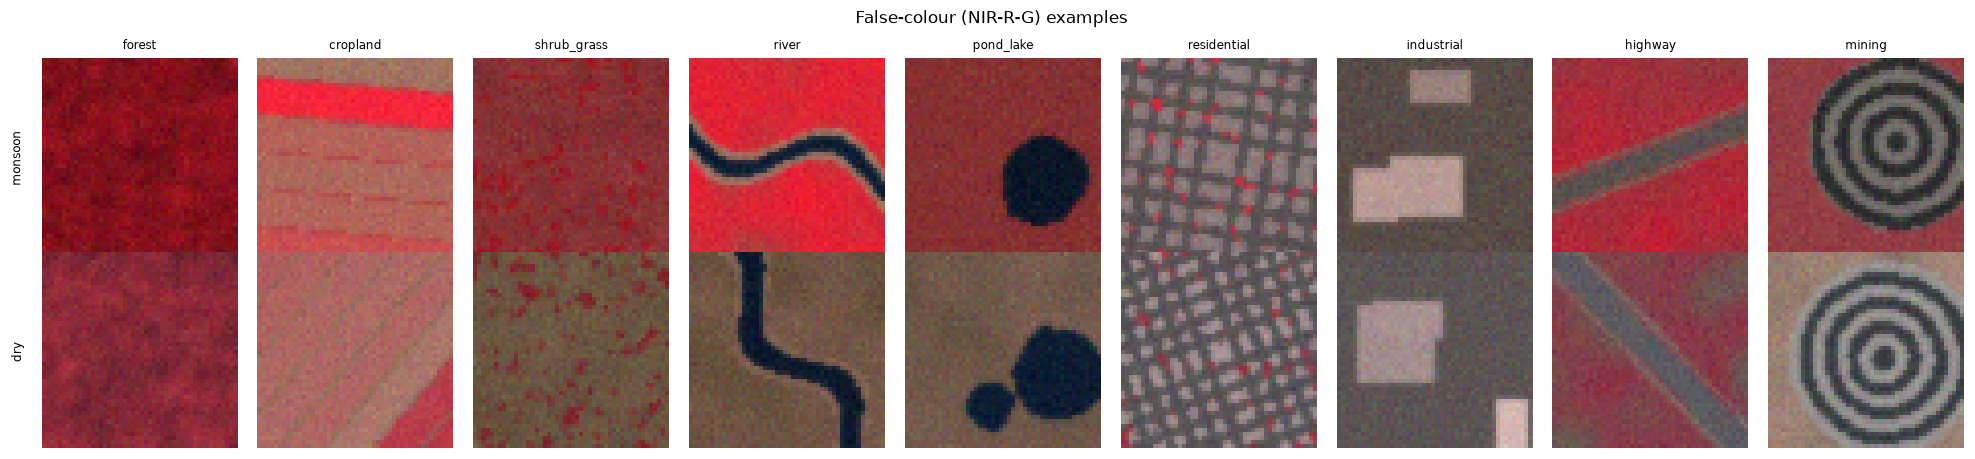

In [2]:
X_unl, _ = ru.make_scene_patches(500, seed=10)                                   # labels discarded
X_lab, y_lab = ru.make_scene_patches(100, seed=11)
X_te, y_te = ru.make_scene_patches(100, seed=12)
X_dry, y_dry = ru.make_scene_patches(100, seed=13, dry=True)
mu, sd = X_unl.mean((0, 2, 3), keepdims=True), X_unl.std((0, 2, 3), keepdims=True)
nrm = lambda a: ((a - mu) / sd).astype(np.float32)
print({k: v.shape for k, v in {"unlabelled": X_unl, "labelled": X_lab, "test": X_te, "test dry": X_dry}.items()})
fig, axes = plt.subplots(2, K, figsize=(18, 4.2))
for k in range(K):
    for row, (Xs, ys, tag) in enumerate([(X_te, y_te, "monsoon"), (X_dry, y_dry, "dry")]):
        i = np.flatnonzero(ys == k)[0]; axes[row, k].imshow(np.clip(Xs[i][[3, 2, 1]].transpose(1, 2, 0) / 0.4, 0, 1)); axes[row, k].axis("off")
    axes[0, k].set_title(CL[k], fontsize=8)
axes[0, 0].text(-8, 24, "monsoon", rotation=90, va="center", fontsize=8); axes[1, 0].text(-8, 24, "dry", rotation=90, va="center", fontsize=8)
plt.suptitle("False-colour (NIR-R-G) examples"); plt.tight_layout(); plt.show()

def subset(n_per_class, seed=0):
    r = np.random.default_rng(seed); return np.concatenate([r.choice(np.flatnonzero(y_lab == k), n_per_class, replace=False) for k in range(K)])

## **2. Encoder Architecture**
A small residual CNN (about 1.2 M parameters) with global average pooling. Residual connections (Day 62) make it easy to train. The same encoder is used from scratch, after pretraining, and for Grad-CAM (we keep a handle on its last convolutional block).

In [3]:
class ResBlock(nn.Module):
    def __init__(self, ci, co, stride):
        super().__init__()
        self.c1, self.b1 = nn.Conv2d(ci, co, 3, stride, 1, bias=False), nn.BatchNorm2d(co)
        self.c2, self.b2 = nn.Conv2d(co, co, 3, 1, 1, bias=False), nn.BatchNorm2d(co)
        self.skip = nn.Sequential() if (ci == co and stride == 1) else nn.Sequential(nn.Conv2d(ci, co, 1, stride, bias=False), nn.BatchNorm2d(co))
    def forward(self, x):
        return F.relu(self.b2(self.c2(F.relu(self.b1(self.c1(x))))) + self.skip(x))

class Encoder(nn.Module):
    def __init__(self, c_in=4, w=32):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(c_in, w, 3, 1, 1, bias=False), nn.BatchNorm2d(w), nn.ReLU())
        self.layers = nn.Sequential(ResBlock(w, w, 1), ResBlock(w, 2 * w, 2), ResBlock(2 * w, 4 * w, 2), ResBlock(4 * w, 8 * w, 2))
        self.dim = 8 * w
    def forward(self, x, return_map=False):
        fmap = self.layers(self.stem(x)); z = fmap.mean((2, 3))
        return (z, fmap) if return_map else z

class Classifier(nn.Module):
    def __init__(self, encoder, n_cls=K):
        super().__init__(); self.encoder = encoder; self.head = nn.Linear(encoder.dim, n_cls)
    def forward(self, x):
        return self.head(self.encoder(x))
print(f"encoder parameters: {sum(p.numel() for p in Encoder().parameters()):,}")

encoder parameters: 1,226,688


## **3. Augmentations for Multispectral Imagery**
Augmentations encode what should **not** change the label:
- **Rotations and flips**: valid for nadir optical scenes (a field is a field in any orientation). Not valid for SAR (Day 94) or for scenes with consistent sun shadows.
- **Random resized crops**: scale invariance
- **Band-wise brightness and contrast jitter, haze, noise**: illumination and atmosphere. RGB hue jitter (as used for photos) would change the spectral information that defines the classes.

In [4]:
def augment(x, strong=True):
    B = x.shape[0]
    k = np.random.randint(4); x = torch.rot90(x, k, (2, 3))
    if np.random.rand() < 0.5: x = x.flip(3)
    if strong:
        s = np.random.randint(30, 49); i, j = np.random.randint(0, 49 - s, 2)
        x = F.interpolate(x[:, :, i:i + s, j:j + s], size=48, mode="bilinear", align_corners=False)
        x = x * (1 + 0.15 * torch.randn(B, 1, 1, 1)) + 0.15 * torch.randn(B, x.shape[1], 1, 1)
        x = x + 0.05 * torch.randn_like(x)
    return x

## **4. Self-Supervised Pretraining (SimCLR)**
Two augmented views of the same patch should map to nearby embeddings, and views of different patches far apart (the NT-Xent loss, Chen et al. 2020; Day 70). No labels are used. A small projection head is used during pretraining and discarded afterwards.

In [5]:
def nt_xent(z1, z2, tau=0.2):
    z = F.normalize(torch.cat([z1, z2]), dim=1); sim = z @ z.T / tau
    n = z1.shape[0]; sim.fill_diagonal_(-1e9)
    targets = torch.cat([torch.arange(n, 2 * n), torch.arange(0, n)])
    return F.cross_entropy(sim, targets)

torch.manual_seed(0); np.random.seed(0)
ssl_enc = Encoder(); proj = nn.Sequential(nn.Linear(ssl_enc.dim, 256), nn.ReLU(), nn.Linear(256, 64))
opt = torch.optim.AdamW(list(ssl_enc.parameters()) + list(proj.parameters()), 2e-3, weight_decay=1e-4)
Xu = torch.as_tensor(nrm(X_unl)); EPOCHS, BS = 12, 256
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS * (len(Xu) // BS))
t0, losses = time.perf_counter(), []
for ep in range(EPOCHS):
    ssl_enc.train(); perm = torch.randperm(len(Xu)); el = []
    for b in range(0, len(Xu) - BS + 1, BS):
        xb = Xu[perm[b:b + BS]]
        loss = nt_xent(proj(ssl_enc(augment(xb))), proj(ssl_enc(augment(xb))))
        opt.zero_grad(); loss.backward(); opt.step(); sched.step(); el.append(loss.item())
    losses.append(np.mean(el))
print(f"SimCLR: {EPOCHS} epochs in {time.perf_counter() - t0:.0f} s; loss {losses[0]:.2f} -> {losses[-1]:.2f}")

SimCLR: 12 epochs in 571 s; loss 4.13 -> 2.84


## **5. Label-Efficiency Experiment (Table 1)**
For 5, 20 and 100 labels per class we compare:
- **RF on statistics**: per-band mean, s.d. and 10th/90th percentiles
- **CNN from scratch**
- **SSL + linear probe**: frozen pretrained encoder, logistic regression on its features
- **SSL + fine-tune**: the whole pretrained network trained on the labels

Every number is averaged over 2 random label draws.

In [6]:
def stats(X):
    return np.concatenate([X.mean((2, 3)), X.std((2, 3)), np.percentile(X, [10, 90], axis=(2, 3)).transpose(1, 0, 2).reshape(len(X), -1)], 1)

@torch.no_grad()
def embed(enc, X):
    enc.eval(); return torch.cat([enc(torch.as_tensor(nrm(X[b:b + 500]))) for b in range(0, len(X), 500)]).numpy()

@torch.no_grad()
def predict(model, X):
    model.eval(); return torch.cat([model(torch.as_tensor(nrm(X[b:b + 500]))) for b in range(0, len(X), 500)]).argmax(1).numpy()

def train_classifier(encoder, idx, epochs=60, lr=1e-3, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    model = Classifier(encoder); opt = torch.optim.AdamW(model.parameters(), lr, weight_decay=1e-3)
    xt, yt = torch.as_tensor(nrm(X_lab[idx])), torch.as_tensor(y_lab[idx])
    steps = max(1, len(idx) // 32); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs * steps)
    for ep in range(epochs):
        model.train(); perm = torch.randperm(len(xt))
        for b in range(steps):
            j = perm[b * 32:(b + 1) * 32]
            loss = F.cross_entropy(model(augment(xt[j], strong=False)), yt[j], label_smoothing=0.1)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    return model

F_unl_te, F_unl_dry = embed(ssl_enc, X_te), embed(ssl_enc, X_dry)
rows = []; t0 = time.perf_counter()
for n_lab in [5, 20, 100]:
    for rep in range(2):
        idx = subset(n_lab, seed=rep)
        rf = RandomForestClassifier(300, n_jobs=-1, random_state=rep).fit(stats(X_lab[idx]), y_lab[idx])
        res = {"RF on statistics": (rf.predict(stats(X_te)), rf.predict(stats(X_dry)))}
        lp = LogisticRegression(C=1.0, max_iter=3000).fit(embed(ssl_enc, X_lab[idx]), y_lab[idx])
        res["SSL + linear probe"] = (lp.predict(F_unl_te), lp.predict(F_unl_dry))
        scratch = train_classifier(Encoder(), idx, seed=rep)
        res["CNN from scratch"] = (predict(scratch, X_te), predict(scratch, X_dry))
        ft = train_classifier(copy.deepcopy(ssl_enc), idx, lr=5e-4, seed=rep)
        res["SSL + fine-tune"] = (predict(ft, X_te), predict(ft, X_dry))
        for m, (p_te, p_dry) in res.items():
            rows.append({"labels per class": n_lab, "rep": rep, "model": m, "accuracy (monsoon test)": accuracy_score(y_te, p_te), "accuracy (dry-season test)": accuracy_score(y_dry, p_dry)})
print(f"experiment took {time.perf_counter() - t0:.0f} s")
lab = pd.DataFrame(rows).groupby(["labels per class", "model"])[["accuracy (monsoon test)", "accuracy (dry-season test)"]].mean().unstack(0)
lab.round(3).to_csv(PROJ / "table1_label_efficiency.csv"); lab.round(3)

experiment took 878 s


accuracy (monsoon test)                \
labels per class                       5      20     100   
model                                                      
CNN from scratch                     0.812  0.996  1.000   
RF on statistics                     0.750  0.897  0.957   
SSL + fine-tune                      0.844  0.999  1.000   
SSL + linear probe                   0.867  0.973  0.994   

                   accuracy (dry-season test)                
labels per class                          5      20     100  
model                                                        
CNN from scratch                        0.600  0.671  0.795  
RF on statistics                        0.563  0.668  0.755  
SSL + fine-tune                         0.545  0.698  0.811  
SSL + linear probe                      0.506  0.562  0.596

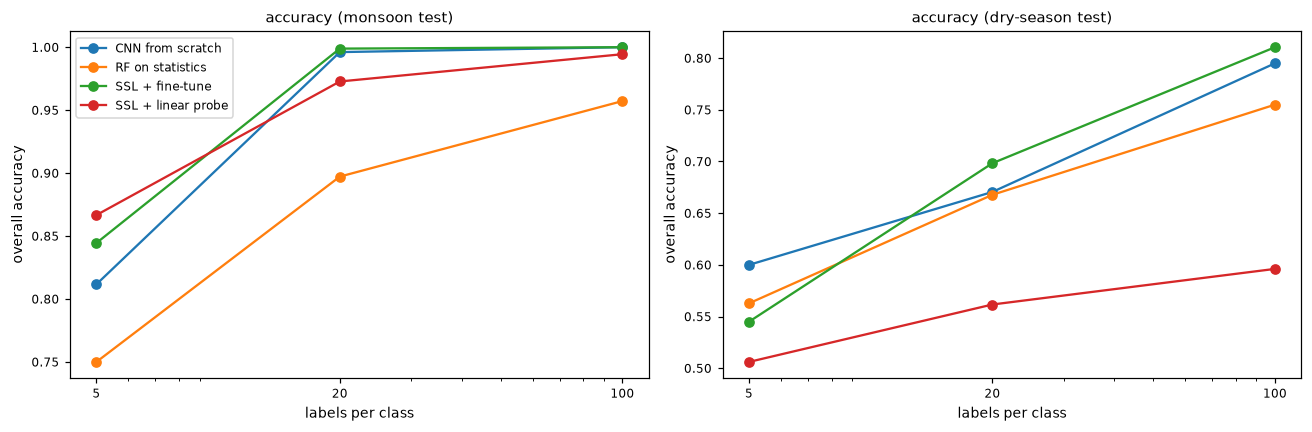

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["accuracy (monsoon test)", "accuracy (dry-season test)"]):
    for m in lab.index: ax.plot([5, 20, 100], lab.loc[m, col].values, "-o", label=m)
    ax.set_xscale("log"); ax.set_xticks([5, 20, 100], ["5", "20", "100"]); ax.set_xlabel("labels per class"); ax.set_ylabel("overall accuracy"); ax.set_title(col)
axes[0].legend(fontsize=8); plt.tight_layout(); fig.savefig(PROJ / "fig1_label_efficiency.png", dpi=300, bbox_inches="tight"); plt.show()

Read the curves from left to right:
- **In-season**, pretraining pays off where labels are scarce. With 5 labels per class, both SSL variants beat the CNN trained from scratch and the RF. With 100 labels, every CNN is near-perfect and the advantage disappears.
- **Dry season**, every model loses accuracy, and the *frozen* SSL features (linear probe) degrade most. A representation learned only from monsoon imagery encodes monsoon spectra, so pretraining is not a cure for a seasonal shift. Fine-tuning recovers part of the loss. The real remedies are training data (labelled or unlabelled) from the target season and multi-season inputs; Practice Problem 4 tests a short version of the first.

## **6. The Final Model: Confusion and Grad-CAM**
We fine-tune the pretrained encoder on all 100 labels per class and inspect the errors.

**Grad-CAM** (Selvaraju et al. 2017) weights the last convolutional feature maps A_k by the spatially averaged gradient of the class score, alpha_k = mean(dy_c / dA_k), and shows ReLU(sum_k alpha_k A_k) upsampled to the image. We expect "river" to light up along the water line, "highway" along the road, and "mining" on the pit.

final model: monsoon test accuracy 1.000, macro F1 1.000; dry-season accuracy 0.819


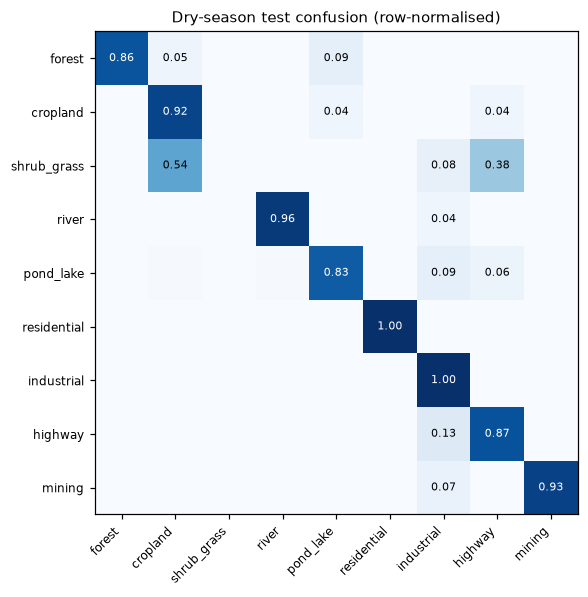

In [8]:
final = train_classifier(copy.deepcopy(ssl_enc), np.arange(len(y_lab)), lr=5e-4, epochs=40)
p_final = predict(final, X_te)
print(f"final model: monsoon test accuracy {accuracy_score(y_te, p_final):.3f}, macro F1 {f1_score(y_te, p_final, average='macro'):.3f}; "
      f"dry-season accuracy {accuracy_score(y_dry, predict(final, X_dry)):.3f}")
cm = confusion_matrix(y_dry, predict(final, X_dry), normalize="true")
fig, ax = plt.subplots(figsize=(6.5, 5.5)); ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
for i in range(K):
    for j in range(K):
        if cm[i, j] > 0.02: ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7, color="w" if cm[i, j] > 0.6 else "k")
ax.set_xticks(range(K), CL, rotation=45, ha="right", fontsize=8); ax.set_yticks(range(K), CL, fontsize=8); ax.set_title("Dry-season test confusion (row-normalised)")
plt.tight_layout(); plt.show()

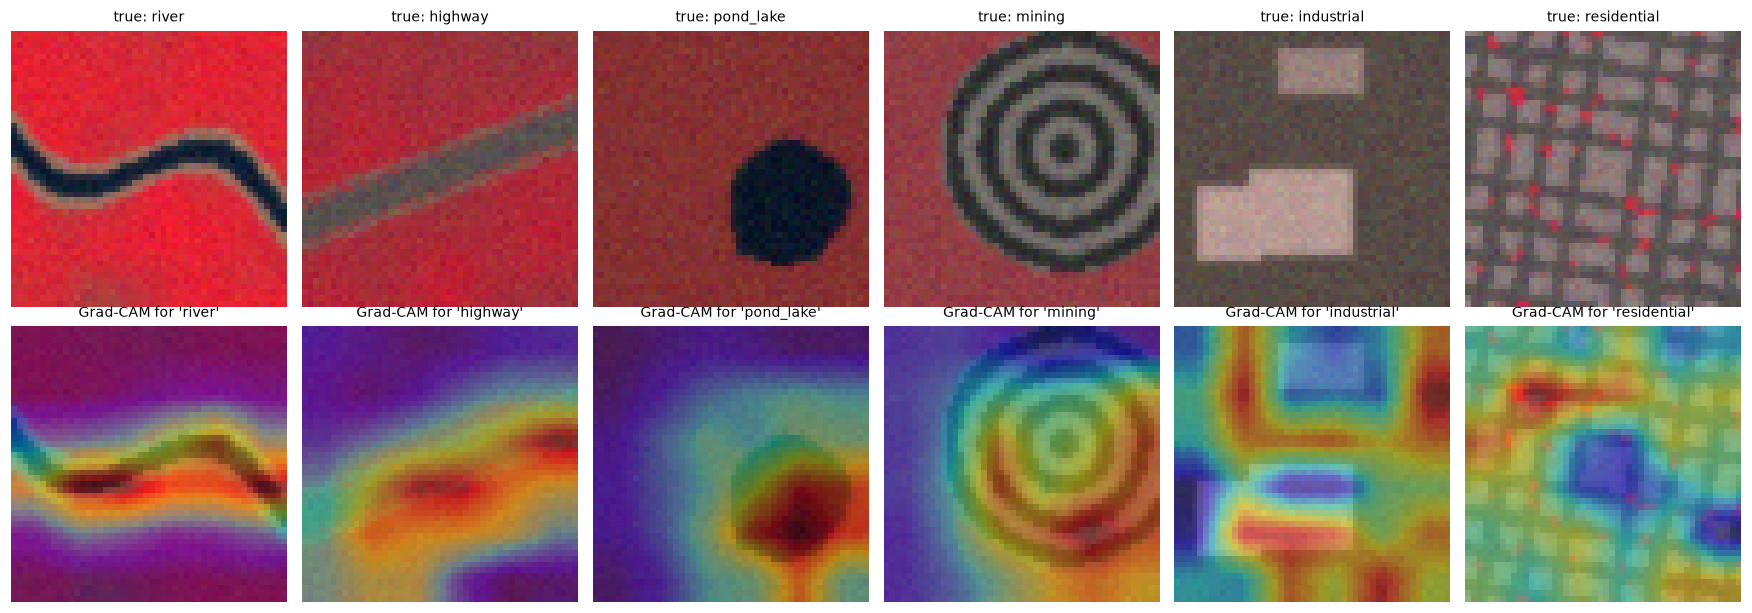

In [9]:
def grad_cam(model, x, cls=None):
    model.eval(); x = torch.as_tensor(nrm(x[None])).requires_grad_(False)
    z, fmap = model.encoder(x, return_map=True); fmap.retain_grad()
    logits = model.head(fmap.mean((2, 3))); c = int(logits.argmax()) if cls is None else cls
    logits[0, c].backward()
    w = fmap.grad.mean((2, 3), keepdim=True); cam = F.relu((w * fmap).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[0, 0].detach().numpy()
    return cam / (cam.max() + 1e-9), c

show = [CL.index(c) for c in ["river", "highway", "pond_lake", "mining", "industrial", "residential"]]
fig, axes = plt.subplots(2, len(show), figsize=(16, 5.6))
for col, k in enumerate(show):
    i = np.flatnonzero(y_te == k)[0]; rgb = np.clip(X_te[i][[3, 2, 1]].transpose(1, 2, 0) / 0.4, 0, 1)
    cam, c = grad_cam(final, X_te[i])
    axes[0, col].imshow(rgb); axes[0, col].set_title(f"true: {CL[k]}", fontsize=9)
    axes[1, col].imshow(rgb); axes[1, col].imshow(cam, cmap="jet", alpha=0.45); axes[1, col].set_title(f"Grad-CAM for '{CL[c]}'", fontsize=9)
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); fig.savefig(PROJ / "fig2_gradcam.png", dpi=300, bbox_inches="tight"); plt.show()

### **Sanity check for explanations**
Adebayo et al. (2018) showed that some saliency methods produce similar maps even for a **randomly initialised** network, so the map reflects the image rather than the model. Run the check: compare Grad-CAM of the trained model with Grad-CAM of a model whose weights are random. The correlation should be low.

In [10]:
def safe_corr(a, b):
    return np.nan if a.std() == 0 or b.std() == 0 else np.corrcoef(a.ravel(), b.ravel())[0, 1]
rand_model = Classifier(Encoder()); corrs = []
for k in show:
    i = np.flatnonzero(y_te == k)[0]
    a, _ = grad_cam(final, X_te[i], cls=k); b, _ = grad_cam(rand_model, X_te[i], cls=k)
    corrs.append(safe_corr(a, b))
print("correlation of Grad-CAM (trained vs random weights):", np.round(corrs, 2), "-> mean", round(float(np.nanmean(corrs)), 2))
print("(nan = the random network produced a completely flat map: no structure at all to correlate with)")

correlation of Grad-CAM (trained vs random weights): [-0.43 -0.05   nan   nan  0.07 -0.29] -> mean -0.17
(nan = the random network produced a completely flat map: no structure at all to correlate with)


# **Part 2: Going Deeper**

## **7. Using Real Pretrained RS Weights**
For real Sentinel-2 work, start from weights pretrained on millions of RS images rather than training SSL ourselves. [TorchGeo](https://github.com/microsoft/torchgeo) packages many of them:

```python
# pip install torchgeo
from torchgeo.models import ResNet18_Weights, resnet18
weights = ResNet18_Weights.SENTINEL2_ALL_MOCO              # MoCo pretrained on SSL4EO-S12, all 13 S2 bands
model = resnet18(weights=weights)                           # timm ResNet-18 with 13 input channels
model.fc = torch.nn.Linear(model.fc.in_features, n_classes)
```

If our data have **different bands** from the pretrained model, adapt the first convolution rather than discarding it:

In [11]:
def adapt_first_conv(conv, band_map):
    """conv: pretrained nn.Conv2d; band_map: for each NEW band, the index of the most similar OLD band (or None = mean of all)."""
    new = nn.Conv2d(len(band_map), conv.out_channels, conv.kernel_size, conv.stride, conv.padding, bias=conv.bias is not None)
    with torch.no_grad():
        for i, j in enumerate(band_map):
            new.weight[:, i] = conv.weight[:, j] if j is not None else conv.weight.mean(1)
        new.weight *= conv.in_channels / len(band_map)                # keep the activation scale
        if conv.bias is not None: new.bias.copy_(conv.bias)
    return new
rgb_conv = nn.Conv2d(3, 64, 7, 2, 3, bias=False)                           # stand-in for an ImageNet ResNet stem (R, G, B)
four_band = adapt_first_conv(rgb_conv, band_map=[2, 1, 0, None])           # our B, G, R map onto ImageNet B, G, R; NIR <- mean
print(four_band, tuple(four_band.weight.shape))

Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False) (64, 4, 7, 7)


## **Practice Problems**
1. Remove rotations from the augmentation. Does fine-tuning with 5 labels per class suffer?
2. Replace the linear probe with a kNN classifier (k = 5) on the SSL features. Which works better with 5 labels?
3. Which pair of classes is most confused in the dry season? Show 4 misclassified examples.
4. *(Advanced)* Continue SimCLR pretraining for 4 epochs on a mix of the unlabelled monsoon patches and 1,800 unlabelled **dry-season** patches, then repeat the 20-label fine-tuning. Does dry-season accuracy improve?

In [12]:
# Solution 1
def augment_norot(x, strong=False):
    return x.flip(3) if np.random.rand() < 0.5 else x
_aug = augment; augment = augment_norot
m_norot = train_classifier(copy.deepcopy(ssl_enc), subset(5), lr=5e-4)
augment = _aug
m_rot = train_classifier(copy.deepcopy(ssl_enc), subset(5), lr=5e-4)
print(f"5 labels/class fine-tune accuracy: without rotations {accuracy_score(y_te, predict(m_norot, X_te)):.3f} | with rotations {accuracy_score(y_te, predict(m_rot, X_te)):.3f}")

5 labels/class fine-tune accuracy: without rotations 0.819 | with rotations 0.821


In [13]:
# Solution 2
from sklearn.neighbors import KNeighborsClassifier
idx = subset(5); Fl = embed(ssl_enc, X_lab[idx])
knn = KNeighborsClassifier(5).fit(Fl / np.linalg.norm(Fl, axis=1, keepdims=True), y_lab[idx])
print(f"kNN on SSL features (5 labels/class): {accuracy_score(y_te, knn.predict(F_unl_te / np.linalg.norm(F_unl_te, axis=1, keepdims=True))):.3f} | "
      f"linear probe: {lab.loc['SSL + linear probe', ('accuracy (monsoon test)', 5)]:.3f}")

kNN on SSL features (5 labels/class): 0.734 | linear probe: 0.867


most confused: true shrub_grass -> predicted cropland (54 cases)


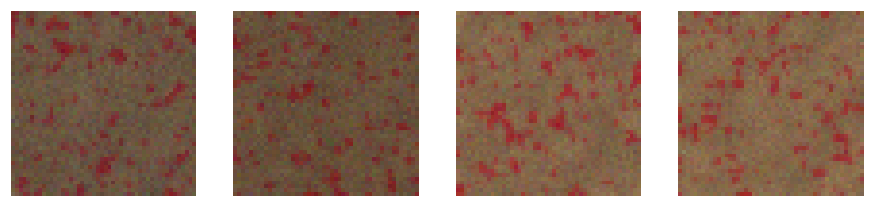

In [14]:
# Solution 3
p_dry = predict(final, X_dry); cmc = confusion_matrix(y_dry, p_dry); np.fill_diagonal(cmc, 0)
a, b = np.unravel_index(cmc.argmax(), cmc.shape); print(f"most confused: true {CL[a]} -> predicted {CL[b]} ({cmc[a, b]} cases)")
wrong = np.flatnonzero((y_dry == a) & (p_dry == b))[:4]
fig, axes = plt.subplots(1, max(1, len(wrong)), figsize=(10, 2.8))
for ax, i in zip(np.atleast_1d(axes), wrong): ax.imshow(np.clip(X_dry[i][[3, 2, 1]].transpose(1, 2, 0) / 0.4, 0, 1)); ax.axis("off")
plt.show()

In [15]:
# Solution 4
X_dry_unl, _ = ru.make_scene_patches(200, seed=20, dry=True)
enc2 = copy.deepcopy(ssl_enc); proj2 = copy.deepcopy(proj); opt2 = torch.optim.AdamW(list(enc2.parameters()) + list(proj2.parameters()), 5e-4)
Xmix = torch.as_tensor(nrm(np.concatenate([X_unl[:1800], X_dry_unl])))
for ep in range(4):
    enc2.train(); perm = torch.randperm(len(Xmix))
    for b in range(0, len(Xmix) - BS + 1, BS):
        xb = Xmix[perm[b:b + BS]]; loss = nt_xent(proj2(enc2(augment(xb))), proj2(enc2(augment(xb))))
        opt2.zero_grad(); loss.backward(); opt2.step()
m_mix = train_classifier(copy.deepcopy(enc2), subset(20), lr=5e-4); m_base = train_classifier(copy.deepcopy(ssl_enc), subset(20), lr=5e-4)
print(f"20 labels/class, dry-season accuracy: monsoon-only SSL {accuracy_score(y_dry, predict(m_base, X_dry)):.3f} | + dry-season SSL {accuracy_score(y_dry, predict(m_mix, X_dry)):.3f}")
print("A few epochs of mixed pretraining are not enough to re-shape the representation; in practice pretrain on all seasons from the start,")
print("or add a handful of labelled dry-season samples (Day 79), which usually helps far more than unlabelled data alone.")

20 labels/class, dry-season accuracy: monsoon-only SSL 0.674 | + dry-season SSL 0.674
A few epochs of mixed pretraining are not enough to re-shape the representation; in practice pretrain on all seasons from the start,
or add a handful of labelled dry-season samples (Day 79), which usually helps far more than unlabelled data alone.


## **Key References**
- Helber, P., Bischke, B., Dengel, A., & Borth, D. (2019). EuroSAT: A novel dataset and deep learning benchmark for land use and land cover classification. *IEEE JSTARS*, 12(7), 2217-2226.
- Chen, T., Kornblith, S., Norouzi, M., & Hinton, G. (2020). A simple framework for contrastive learning of visual representations. *ICML 2020*, PMLR 119, 1597-1607.
- Wang, Y., Braham, N. A. A., Xiong, Z., Liu, C., Albrecht, C. M., & Zhu, X. X. (2023). SSL4EO-S12: A large-scale multimodal, multitemporal dataset for self-supervised learning in Earth observation. *IEEE Geoscience and Remote Sensing Magazine*, 11(3), 98-106.
- Stewart, A. J. et al. (2022). TorchGeo: Deep learning with geospatial data. *Proceedings of the 30th ACM SIGSPATIAL*, 1-12.
- Selvaraju, R. R. et al. (2017). Grad-CAM: Visual explanations from deep networks via gradient-based localization. *ICCV 2017*, 618-626.
- Adebayo, J. et al. (2018). Sanity checks for saliency maps. *Advances in Neural Information Processing Systems*, 31.
- Cong, Y. et al. (2022). SatMAE: Pre-training transformers for temporal and multi-spectral satellite imagery. *Advances in Neural Information Processing Systems*, 35.
- Neumann, M., Pinto, A. S., Zhai, X., & Houlsby, N. (2019). In-domain representation learning for remote sensing. *arXiv:1911.06721*.